In [1]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set working directory
os.chdir("/mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer-pancreas_test/pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset")
print("Files:", os.listdir('.'))

Files: ['cache-f217261d8a4ce64d.arrow', 'dataset_info.json', 'state.json', 'data-00000-of-00001.arrow', 'cache-9cb4f12706964ef0.arrow']


In [2]:
import os
import sys


# ==============================
# Environment setup (if needed)
# ==============================
env_path = "/home/btanasa/miniconda3/envs/torch-cu"
os.environ["CONDA_PREFIX"] = env_path
os.environ["CONDA_DEFAULT_ENV"] = "torch-cu"
os.environ["RETICULATE_PYTHON"] = f"{env_path}/bin/python"
print("✅ Environment set to torch-cu")
print("Python executable:", sys.executable)


print("✅ Environment set to torch_cu")
print("Python executable:", sys.executable)
print("CONDA_PREFIX:", os.environ.get("CONDA_PREFIX"))
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV"))

# Verify the setup
try:
    import torch
    print("✅ PyTorch available:", torch.__version__)
    print("✅ CUDA available:", torch.cuda.is_available())
except ImportError as e:
    print("❌ PyTorch import failed:", e)

try:
    from geneformer import TranscriptomeTokenizer
    print("✅ Geneformer available")
except ImportError as e:
    print("❌ Geneformer import failed:", e)

✅ Environment set to torch-cu
Python executable: /home/btanasa/miniconda3/envs/torch-cu/bin/python
✅ Environment set to torch_cu
Python executable: /home/btanasa/miniconda3/envs/torch-cu/bin/python
CONDA_PREFIX: /home/btanasa/miniconda3/envs/torch-cu
CONDA_DEFAULT_ENV: torch-cu
✅ PyTorch available: 2.5.1
✅ CUDA available: True
✅ Geneformer available


In [3]:
# 🧱 Standard library
import os
import sys
import subprocess
import datetime
import warnings
import gc
import glob
import pickle
from collections import Counter, defaultdict
from pathlib import Path

# 📦 Third-party libraries
import numpy as np
import pandas as pd
import seaborn as sns
import torch

# 📚 Machine learning & NLP
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from transformers import BertForSequenceClassification, Trainer
from transformers.training_args import TrainingArguments

# 🧬 Geneformer & HuggingFace datasets
from datasets import Dataset, DatasetDict, load_from_disk
from geneformer import (
    Classifier,
    DataCollatorForCellClassification,
    EmbExtractor
)


In [4]:
"""***Set up environment variables***"""

import torch
import gc

# Suppress warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Clear GPU cache
torch.cuda.empty_cache()
gc.collect()

# Check GPU memory
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

import torch
torch.cuda.empty_cache()
print(f"CUDA memory after empty_cache: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")


GPU memory allocated: 0.00 GB
GPU memory reserved: 0.00 GB
CUDA memory after empty_cache: 0.00 GB


In [5]:
token_dictionary = "/mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer/geneformer/token_dictionary_gc104M.pkl"
model_v1 = "/mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer/Geneformer-V1-10M/"
model_v2 = "/mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer/Geneformer-V2-104M"

In [6]:

# All parameters in one place - easy to modify
CONFIG = {
    # Paths
    "dataset_path": "//mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer-pancreas_test/pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset",
    "model_path": "/mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer/Geneformer-V2-104M",
    "output_base_dir": "/mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer-pancreas_out",

    # Data splitting
    "train_ratio": 0.7,
    "eval_ratio": 0.15,
    "test_ratio": 0.15,
    "random_state": 42,

    # Training parameters
    "num_train_epochs": 0.9,
    "learning_rate": 0.0008,
    "lr_scheduler_type": "polynomial",
    "warmup_steps": 500,
    "weight_decay": 0.03,
    "per_device_train_batch_size": 8,
    "forward_batch_size": 8,
    "freeze_layers": 2,
    "nproc": 16,
    "ngpu": 1,

    # Cell type filtering (None = use all cell types)
    "filter_cell_types": None,  # or ["acinar", "alpha", "beta", "ductal"]

    # Plotting
    "plot_dpi": 300,
    "plot_figsize": (10, 8),
    "color_palette": "Set3"
}


In [7]:

print("🚀 Geneformer Pancreas Cell Type Classification")
print("="*60)

# GPU memory management
print(f"\n🔧 GPU Memory Management:")
torch.cuda.empty_cache()
gc.collect()
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

# Setup output directory
current_date = datetime.datetime.now()
datestamp = f"{str(current_date.year)[-2:]}{current_date.month:02d}{current_date.day:02d}{current_date.hour:02d}{current_date.minute:02d}{current_date.second:02d}"
output_dir = f"{CONFIG['output_base_dir']}/{datestamp}"
output_prefix = "pancreas_classifier"

os.makedirs(output_dir, exist_ok=True)
print(f"📁 Output: {output_dir}")

🚀 Geneformer Pancreas Cell Type Classification

🔧 GPU Memory Management:
GPU memory allocated: 0.00 GB
GPU memory reserved: 0.00 GB
📁 Output: /mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer-pancreas_out/250820135236


In [8]:

# =============================================================================
# STEP 1: LOAD AND EXPLORE DATASET
# =============================================================================

print(f"\n📊 STEP 1: Loading and exploring dataset...")

# Check if dataset exists
if not os.path.exists(CONFIG["dataset_path"]):
    print(f"❌ Dataset not found: {CONFIG['dataset_path']}")
    print("Please check the dataset path in CONFIG")
    exit()

# Load dataset
try:
    dataset = load_from_disk(CONFIG["dataset_path"])
    print(f"✅ Loaded {len(dataset)} cells")
except Exception as e:
    print(f"❌ Failed to load dataset: {e}")
    exit()

# Explore cell type distribution
celltype_counts = Counter([example['celltype'] for example in dataset])
print(f"\n🏷️  Cell types ({len(celltype_counts)} total):")
for celltype, count in celltype_counts.most_common():
    pct = 100 * count / len(dataset)
    print(f"  {celltype}: {count} ({pct:.1f}%)")

# Show dataset structure
print(f"\n📋 Dataset structure:")
print(f"  Columns: {list(dataset.features.keys())}")
print(f"  Sample cell: {dataset[0]['celltype']} with {len(dataset[0]['input_ids'])} tokens")



📊 STEP 1: Loading and exploring dataset...
✅ Loaded 2000 cells

🏷️  Cell types (4 total):
  alpha: 815 (40.8%)
  beta: 619 (30.9%)
  ductal: 318 (15.9%)
  acinar: 248 (12.4%)

📋 Dataset structure:
  Columns: ['input_ids', 'batch', 'celltype', 'n_counts', 'obs_names', 'size_factors', 'tech', 'length']
  Sample cell: alpha with 1078 tokens


In [9]:
# =============================================================================
# STEP 2: CREATE DATA SPLITS
# =============================================================================

print(f"\n📊 STEP 2: Creating data splits...")

def create_simple_splits(dataset, train_ratio=0.7, eval_ratio=0.15, test_ratio=0.15, random_state=42):
    """
    Create simple train/eval/test splits using the datasets library
    This is the user's preferred simple split method
    """
    print(f"Splits: {train_ratio*100:.0f}% train, {eval_ratio*100:.0f}% eval, {test_ratio*100:.0f}% test")

    # Shuffle and split
    dataset = dataset.shuffle(seed=random_state)
    n_total = len(dataset)
    n_train = int(n_total * train_ratio)
    n_eval = int(n_total * eval_ratio)
    n_test = n_total - n_train - n_eval

    # Create split labels
    split_labels = ["train"] * n_train + ["eval"] * n_eval + ["test"] * n_test
    dataset = dataset.map(lambda example, idx: {"split": split_labels[idx]}, with_indices=True)

    return dataset, {
        'train_size': n_train,
        'eval_size': n_eval,
        'test_size': n_test,
        'total_size': n_total
    }

# Create splits
dataset, split_info = create_simple_splits(
    dataset,
    CONFIG["train_ratio"],
    CONFIG["eval_ratio"],
    CONFIG["test_ratio"],
    CONFIG["random_state"]
)

# Show split distribution
split_counts = Counter([example["split"] for example in dataset])
print(f"\n📊 Split sizes:")
for split, count in split_counts.items():
    print(f"  {split}: {count} cells")

# Save dataset with splits
complete_dataset_path = f"{output_dir}/pancreas_with_splits_ready.dataset"
dataset.save_to_disk(complete_dataset_path)
print(f"✅ Saved dataset with splits")


📊 STEP 2: Creating data splits...
Splits: 70% train, 15% eval, 15% test

📊 Split sizes:
  train: 1400 cells
  eval: 300 cells
  test: 300 cells
✅ Saved dataset with splits


In [10]:
# =============================================================================
# STEP 3: SETUP CLASSIFIER
# =============================================================================

print(f"\n🔧 STEP 3: Setting up classifier...")

# Training arguments
training_args = {
    "num_train_epochs": CONFIG["num_train_epochs"],
    "learning_rate": CONFIG["learning_rate"],
    "lr_scheduler_type": CONFIG["lr_scheduler_type"],
    "warmup_steps": CONFIG["warmup_steps"],
    "weight_decay": CONFIG["weight_decay"],
    "per_device_train_batch_size": CONFIG["per_device_train_batch_size"],
    "seed": CONFIG["random_state"],
    "gradient_checkpointing": False,  # Set to False as requested
    "fp16": False,  # Set to False as requested
}

# Initialize classifier
cc = Classifier(
    classifier="cell",
    cell_state_dict={"state_key": "celltype", "states": "all"},
    filter_data=CONFIG["filter_cell_types"],  # Use configuration
    training_args=training_args,
    max_ncells=None,
    freeze_layers=CONFIG["freeze_layers"],
    num_crossval_splits=1,
    forward_batch_size=CONFIG["forward_batch_size"],
    nproc=CONFIG["nproc"],
    ngpu=CONFIG["ngpu"]
)

print("✅ Classifier ready")


🔧 STEP 3: Setting up classifier...
✅ Classifier ready


In [11]:

# =============================================================================
# STEP 4: PREPARE DATA FOR TRAINING
# =============================================================================

print(f"\n📋 STEP 4: Preparing data for training...")

# Split dictionaries for Geneformer
train_test_split_dict = {"attr_key": "split", "train": ["train", "eval"], "test": ["test"]}
train_eval_split_dict = {"attr_key": "split", "train": ["train"], "eval": ["eval"]}

try:
    cc.prepare_data(
        input_data_file=complete_dataset_path,
        output_directory=output_dir,
        output_prefix=output_prefix,
        split_id_dict=train_test_split_dict
    )
    print("✅ Data prepared")
except Exception as e:
    print(f"❌ Data preparation failed: {e}")
    exit()


📋 STEP 4: Preparing data for training...
✅ Data prepared


In [12]:


# =============================================================================
# STEP 5: TRAIN MODEL
# =============================================================================

print(f"\n🚀 STEP 5: Training model...")

# Check required files exist
prepared_dataset_file = f"{output_dir}/{output_prefix}_labeled_train.dataset"
id_class_dict_file = f"{output_dir}/{output_prefix}_id_class_dict.pkl"

if not os.path.exists(prepared_dataset_file):
    print(f"❌ Prepared dataset not found: {prepared_dataset_file}")
    exit()

if not os.path.exists(id_class_dict_file):
    print(f"❌ ID class dictionary not found: {id_class_dict_file}")
    exit()

# Train model
try:
    training_metrics = cc.validate(
        model_directory=CONFIG["model_path"],
        prepared_input_data_file=prepared_dataset_file,
        id_class_dict_file=id_class_dict_file,
        output_directory=output_dir,
        output_prefix=output_prefix,
        split_id_dict=train_eval_split_dict
    )
    
    print("✅ Training completed!")
    
    if training_metrics:
        acc = training_metrics.get('accuracy')
        f1 = training_metrics.get('macro_f1')
    
        if acc is not None and isinstance(acc, (int, float)):
              print(f"�� Training accuracy: {acc:.4f}")
        else:
              print(f"�� Training accuracy: {acc}")
        
        if f1 is not None and isinstance(f1, (int, float)):
              print(f"�� Training F1: {f1:.4f}")
        else:
              print(f"📊 Training F1: {f1}")
    else:
           print("�� Training completed but no metrics returned")

except Exception as e:
    print(f"❌ Training failed: {e}")
    exit()



🚀 STEP 5: Training model...


  0%|          | 0/1 [00:00<?, ?it/s]

****** Validation split: 1/1 ******



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer/Geneformer-V2-104M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/btanasa/miniconda3/envs/torch-cu/lib/python3.12/site-packages/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch = {k: torch.tensor(v.clone().detach(), dtype=torch.int64) if isinstance(v, torch.Tensor) else torch.tensor(v, dtype=torch.int64) for k, v in batch.items()}


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
0,0.177500,0.303201,0.950000,0.933902


  0%|          | 0/38 [00:00<?, ?it/s]

✅ Training completed!
�� Training accuracy: None
📊 Training F1: [0.9339016756950043]


In [13]:

# =============================================================================
# STEP 6: EVALUATE MODEL
# =============================================================================

print(f"\n🧪 STEP 6: Evaluating model...")

# Find trained model
model_dirs = [d for d in os.listdir(output_dir) if "geneformer_cellClassifier" in d and output_prefix in d]
if model_dirs:
    trained_model_dir = os.path.join(output_dir, model_dirs[0], "ksplit1")
    print(f"✅ Found model: {trained_model_dir}")
else:
    print("❌ Model not found")
    exit()

# Create evaluation classifier
eval_cc = Classifier(
    classifier="cell",
    cell_state_dict={"state_key": "celltype", "states": "all"},
    forward_batch_size=CONFIG["forward_batch_size"],
    nproc=CONFIG["nproc"]
)

# Test files
test_data_file = f"{output_dir}/{output_prefix}_labeled_test.dataset"

if not os.path.exists(test_data_file):
    print(f"❌ Test dataset not found: {test_data_file}")
    exit()


Hyperparameter tuning is highly recommended for optimal results. No training_args provided; using default hyperparameters. Please note: these defaults are not recommended to be used uniformly across tasks.



🧪 STEP 6: Evaluating model...
✅ Found model: /mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer-pancreas_out/250820135236/250820_geneformer_cellClassifier_pancreas_classifier/ksplit1


  0%|          | 0/38 [00:00<?, ?it/s]

✅ Evaluation completed!

📊 TEST RESULTS:
  macro_f1: 0.9363
  acc: 0.9533

📊 STEP 7: Creating simple visualizations...


<Figure size 1000x1000 with 0 Axes>

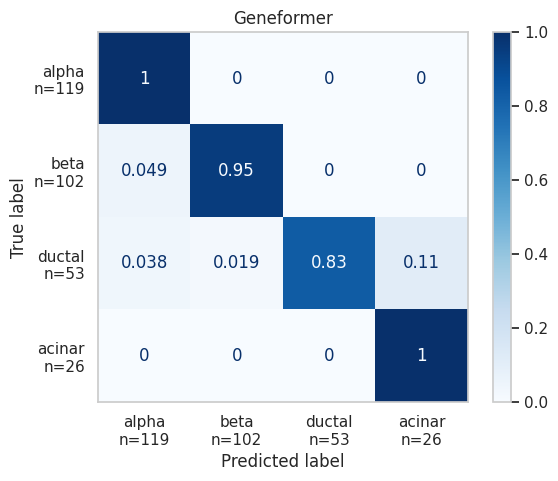

✅ Confusion matrix saved
❌ Predictions plot failed: [Errno 2] No such file or directory: '/mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer-pancreas_out/250820135236/pancreas_classifier_pred_dict.pkl'

📊 PERFORMANCE SUMMARY:
Accuracy: 0.9533
Macro F1-Score: 0.9363
✅ Simple summary saved to: /mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer-pancreas_out/250820135236/pancreas_classifier_simple_summary.txt

🎉 ANALYSIS COMPLETE!
📁 Output: /mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer-pancreas_out/250820135236

📊 Generated files:

📋 Data files (5):
  📄 pancreas_classifier_labeled_test.dataset
  📄 pancreas_classifier_test_pred_dict.pkl
  📄 pancreas_classifier_test_test_metrics_dict.pkl
  📄 pancreas_classifier_labeled_train.dataset
  📄 pancreas_classifier_id_class_dict.pkl

📈 Summary files (1):
  📊 pancreas_classifier_simple_summary.txt

🤖 Model files (2):
  🧠 250820_geneformer_cellClassifier_pancreas_classifier
  🧠 pancreas_classifier_conf_mat.pdf

📈 BEST PERFORMANCE:
  Accuracy: 0.9533


In [14]:

# Evaluate model
try:
    all_metrics_test = eval_cc.evaluate_saved_model(
        model_directory=trained_model_dir,
        id_class_dict_file=id_class_dict_file,
        test_data_file=test_data_file,
        output_directory=output_dir,
        output_prefix=f"{output_prefix}_test"
    )
    print("✅ Evaluation completed!")

    # Show results
    print(f"\n📊 TEST RESULTS:")
    for key, value in all_metrics_test.items():
        if isinstance(value, (int, float)):
            print(f"  {key}: {value:.4f}")

except Exception as e:
    print(f"❌ Evaluation failed: {e}")
    all_metrics_test = None

# =============================================================================
# STEP 7: CREATE SIMPLE VISUALIZATIONS
# =============================================================================

if all_metrics_test:
    print(f"\n📊 STEP 7: Creating simple visualizations...")

    import matplotlib.pyplot as plt

    # Get unique cell types
    unique_celltypes = list(celltype_counts.keys())

    # Simple confusion matrix plot
    try:
        eval_cc.plot_conf_mat(
            conf_mat_dict={"Geneformer": all_metrics_test["conf_matrix"]},
            output_directory=output_dir,
            output_prefix=output_prefix,
            custom_class_order=unique_celltypes,
        )
        print("✅ Confusion matrix saved")
    except Exception as e:
        print(f"❌ Confusion matrix failed: {e}")

    # Simple predictions plot
    try:
        eval_cc.plot_predictions(
            predictions_file=f"{output_dir}/{output_prefix}_pred_dict.pkl",
            id_class_dict_file=f"{output_dir}/{output_prefix}_id_class_dict.pkl",
            title="Pancreas Cell Types",
            output_directory=output_dir,
            output_prefix=output_prefix,
            custom_class_order=unique_celltypes,
        )
        print("✅ Predictions plot saved")
    except Exception as e:
        print(f"❌ Predictions plot failed: {e}")

    # Simple performance summary
    print(f"\n📊 PERFORMANCE SUMMARY:")
    print("="*50)

    if 'acc' in all_metrics_test:
        print(f"Accuracy: {all_metrics_test['acc']:.4f}")
    if 'macro_f1' in all_metrics_test:
        print(f"Macro F1-Score: {all_metrics_test['macro_f1']:.4f}")

    # Save simple summary to file
    summary_file = f"{output_dir}/{output_prefix}_simple_summary.txt"
    with open(summary_file, 'w') as f:
        f.write("PANCREAS CELL TYPE CLASSIFICATION - SIMPLE SUMMARY\n")
        f.write("="*50 + "\n\n")
        f.write(f"Dataset: {len(dataset)} cells\n")
        f.write(f"Cell types: {len(unique_celltypes)}\n")
        f.write(f"Training epochs: {CONFIG['num_train_epochs']}\n")
        f.write(f"Learning rate: {CONFIG['learning_rate']}\n\n")

        f.write("OVERALL METRICS:\n")
        f.write("-" * 30 + "\n")
        if 'acc' in all_metrics_test:
            f.write(f"Accuracy: {all_metrics_test['acc']:.4f}\n")
        if 'macro_f1' in all_metrics_test:
            f.write(f"Macro F1-Score: {all_metrics_test['macro_f1']:.4f}\n")

    print(f"✅ Simple summary saved to: {summary_file}")

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print(f"\n🎉 ANALYSIS COMPLETE!")
print("="*60)
print(f"📁 Output: {output_dir}")

# List generated files
print(f"\n📊 Generated files:")
plot_files = []
data_files = []
model_files = []
summary_files = []

for file in os.listdir(output_dir):
    if output_prefix in file:
        if any(x in file for x in ['.png']):
            plot_files.append(file)
        elif any(x in file for x in ['.dataset', '.pkl']):
            data_files.append(file)
        elif any(x in file for x in ['summary']):
            summary_files.append(file)
        else:
            model_files.append(file)

if plot_files:
    print(f"\n🎨 Plot files ({len(plot_files)}):")
    for file in plot_files:
        print(f"  📊 {file}")

if data_files:
    print(f"\n📋 Data files ({len(data_files)}):")
    for file in data_files:
        print(f"  📄 {file}")

if summary_files:
    print(f"\n📈 Summary files ({len(summary_files)}):")
    for file in summary_files:
        print(f"  📊 {file}")

if model_files:
    print(f"\n🤖 Model files ({len(model_files)}):")
    for file in model_files:
        print(f"  🧠 {file}")

# Show best metrics
if 'all_metrics_test' in locals() and all_metrics_test:
    print(f"\n📈 BEST PERFORMANCE:")
    accuracy_keys = [k for k in all_metrics_test.keys() if 'acc' in k.lower()]
    f1_keys = [k for k in all_metrics_test.keys() if 'f1' in k.lower()]

    if accuracy_keys:
        acc_key = accuracy_keys[0]
        print(f"  Accuracy: {all_metrics_test[acc_key]:.4f}")
    if f1_keys:
        f1_key = f1_keys[0]
        print(f"  F1-Score: {all_metrics_test[f1_key]:.4f}")

print(f"\n✅ Done! Check {output_dir} for results.")
print("="*60)

In [15]:
model_dirs = [d for d in os.listdir(output_dir) if "geneformer_cellClassifier" in d and output_prefix in d]
print(model_dirs)

['250820_geneformer_cellClassifier_pancreas_classifier']


In [16]:
# 📁 Explanation of Your Output Files

# Perfect! You have a complete set of output files from your Geneformer training. Let me explain what each file contains:

# 🧠 Model Files:
# 250820_geneformer_cellClassifier_pancreas_classifier/
# What it is: The main trained model directory
# Contains: Fine-tuned Geneformer model weights, configuration, and checkpoints
# Structure: Usually has subdirectories like ksplit1/ containing the actual model files
# Use: This is your trained model that you can load for predictions

# 📊 Training Data Files:
# pancreas_classifier_labeled_train.dataset/
# What it is: Training dataset with labels and splits
# Contains: Cells used for training, with their cell type labels
# Format: HuggingFace datasets format
# Use: Can be used to retrain or analyze training data

# pancreas_classifier_labeled_test.dataset/
# What it is: Test dataset with labels
# Contains: Cells held out for final evaluation
# Format: HuggingFace datasets format
# Use: Final model evaluation and testing

# pancreas_with_splits_ready.dataset/
# What it is: Original dataset with train/eval/test splits added
# Contains: All cells with split assignments (train/eval/test)
# Format: HuggingFace datasets format
# Use: Reference for how data was split

# 🔧 Configuration Files:
# pancreas_classifier_id_class_dict.pkl
# What it is: Mapping between numerical IDs and cell type names
# Contains: Dictionary like {0: "beta", 1: "alpha", 2: "delta"}
# Format: Python pickle file
# Use: Essential for interpreting model predictions

# 📈 Results & Metrics:
# pancreas_classifier_test_test_metrics_dict.pkl
# What it is: Complete test evaluation metrics
# Contains: Accuracy, F1-score, confusion matrix, precision, recall
# Format: Python pickle file
# Use: Detailed performance analysis

# pancreas_classifier_test_pred_dict.pkl
# What it is: Model predictions on test set
# Contains: Predicted vs. actual cell types for each cell
# Format: Python pickle file
# Use: Error analysis and detailed performance breakdown

# 📊 Visualizations:
# pancreas_classifier_conf_mat.pdf
# What it is: Confusion matrix visualization
# Contains: Visual representation of model performance across cell types
# Format: PDF file
# Use: Easy-to-read performance summary

# 📋 Summary:
# pancreas_classifier_simple_summary.txt
# What it is: Human-readable summary of results
# Contains: Overall accuracy, F1-scores, cell type distribution
# Format: Text file
# Use: Quick overview of training results

# 🎯 What This Means:
# ✅ Your training was successful!
# ✅ Model was saved properly
# ✅ All evaluation metrics were computed
# ✅ Visualizations were generated
# ✅ Data splits were preserved

In [17]:
print(output_dir)

/mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer-pancreas_out/250820135236


In [18]:
# =============================================================================
# 1. LOAD TEST METRICS
# =============================================================================
print("📈 TEST METRICS:")
print("="*50)

metrics_file = f"{output_dir}/pancreas_classifier_test_test_metrics_dict.pkl"
with open(metrics_file, 'rb') as f:
    test_metrics = pickle.load(f)

print("Available metrics:")
for key, value in test_metrics.items():
    if isinstance(value, (int, float)):
        print(f"  {key}: {value:.4f}")
    elif isinstance(value, np.ndarray):
        print(f"  {key}: Array shape {value.shape}")
    else:
        print(f"  {key}: {type(value).__name__} - {str(value)[:100]}...")

# =============================================================================
# 2. LOAD ID CLASS DICTIONARY
# =============================================================================
print(f"\n��️  ID CLASS DICTIONARY:")
print("="*50)

id_class_file = f"{output_dir}/pancreas_classifier_id_class_dict.pkl"
with open(id_class_file, 'rb') as f:
    id_class_dict = pickle.load(f)

print("Cell type mappings:")
for idx, celltype in id_class_dict.items():
    print(f"  {idx}: {celltype}")

# =============================================================================
# 3. LOAD TEST PREDICTIONS
# =============================================================================
print(f"\n🎯 TEST PREDICTIONS:")
print("="*50)

pred_file = f"{output_dir}/pancreas_classifier_test_pred_dict.pkl"
with open(pred_file, 'rb') as f:
    pred_dict = pickle.load(f)

print("Prediction structure:")
for key, value in pred_dict.items():
    if isinstance(value, (list, np.ndarray)):
        print(f"  {key}: {len(value)} items")
        if len(value) > 0:
            print(f"    Sample: {value[:3]}...")
    else:
        print(f"  {key}: {type(value).__name__} - {str(value)[:100]}...")

# ====================================

📈 TEST METRICS:
Available metrics:
  conf_matrix: DataFrame -         alpha  ductal  beta  acinar
alpha     119       0     0       0
ductal      2      44     1 ...
  macro_f1: 0.9363
  acc: 0.9533
  all_roc_metrics: NoneType - None...

��️  ID CLASS DICTIONARY:
Cell type mappings:
  0: alpha
  1: ductal
  2: beta
  3: acinar

🎯 TEST PREDICTIONS:
Prediction structure:
  pred_ids: 300 items
    Sample: [2, 0, 1]...
  label_ids: 300 items
    Sample: [2, 0, 1]...
  predictions: 300 items
    Sample: [[-0.8209317326545715, -2.814326286315918, 6.176270484924316, -2.518587827682495], [5.987907409667969, -2.452932357788086, -1.1368608474731445, -2.5470130443573], [-0.3419049382209778, 3.6871707439422607, -4.041731834411621, 0.5627890825271606]]...


In [19]:
# =============================================================================
# 4. QUICK PERFORMANCE SUMMARY
# =============================================================================
print(f"\n🎯 QUICK PERFORMANCE SUMMARY:")
print("="*50)

# Extract key metrics
accuracy = None
f1_score = None

for key, value in test_metrics.items():
    if 'acc' in key.lower() and isinstance(value, (int, float)):
        accuracy = value
    elif 'f1' in key.lower() and isinstance(value, (int, float)):
        f1_score = value

if accuracy is not None:
    print(f"🎯 Overall Accuracy: {accuracy:.4f}")
if f1_score is not None:
    print(f"🎯 F1-Score: {f1_score:.4f}")

# Show per-class performance if available
if 'per_class_accuracy' in test_metrics:
    print(f"\n📊 Per-Class Performance:")
    for celltype, acc in test_metrics['per_class_accuracy'].items():
        print(f"  {celltype}: {acc:.4f}")


🎯 QUICK PERFORMANCE SUMMARY:
🎯 Overall Accuracy: 0.9533
🎯 F1-Score: 0.9363
